# Notebook — Preparation & Feature Engineering

Ce notebook présente une démarche complète sur le jeu de données **Home Credit Default Risk** :
1. chargement et compréhension des données 
2. analyse de la cible et des valeurs manquantes 
3. identification et préparation des variables catégorielles (Label Encoding + One-Hot Encoding)
4. analyse et correction de l'anomalie sur `DAYS_BIRTH` / `DAYS_EMPLOYED`
5. corrélations, EXT_SOURCE et Pairs Plot 
6. Feature Engineering : Polynomial Features et Domain Knowledge Features 
7. imputation, normalisation et séparation train / validation
8. sauvegarde des jeux de données 



## Installation et import des bibliothèques

In [ ]:
# --- MANIPULATION DE DONNÉES & CALCUL NUMÉRIQUE ---
import numpy as np  # Calcul matriciel, opérations mathématiques et gestion des tableaux multidimensionnels
import pandas as pd  # Manipulation, nettoyage et analyse de données structurées (DataFrames)

# --- VISUALISATION DE DONNÉES ---
import matplotlib.pyplot as plt  # Création de graphiques basiques (histogrammes, courbes, nuages de points)
import seaborn as sns  # Visualisation avancée et stylisée basée sur Matplotlib (heatmaps, matrices de confusion)

# --- PRÉTRAITEMENT DES DONNÉES (Scikit-Learn) ---
from sklearn.preprocessing import LabelEncoder, MinMaxScaler  # LabelEncoder: encodage des variables catégorielles en chiffres
                                                              # MinMaxScaler: normalisation des variables numériques entre 0 et 1
from sklearn.impute import SimpleImputer  # Gestion et remplacement des valeurs manquantes (ex: par la médiane ou la moyenne)
from sklearn.model_selection import train_test_split  # Découpage du jeu de données en sous-ensembles d'entraînement et de validation

# PCA
from sklearn.decomposition import PCA  # Analyse en Composantes Principales
from sklearn.preprocessing import StandardScaler

# --- MÉTRIQUES D'ÉVALUATION (Scikit-Learn) ---
from sklearn.metrics import (
    roc_auc_score,       # Calcul de l'aire sous la courbe ROC (capacité de séparation du modèle)
    accuracy_score,      # Taux global de bonnes prédictions
    precision_score,     # Proportion de vrais positifs parmi les prédictions positives
    recall_score,        # Proportion de vrais positifs détectés parmi tous les cas positifs réels (sensibilité)
    f1_score,            # Moyenne harmonique entre Précision et Rappel
    confusion_matrix     # Matrice comparant les classes réelles et les classes prédites
)

# --- GESTION DES AVERTISSEMENTS ---
import warnings
warnings.filterwarnings("ignore")  



## Chargement des données

In [2]:
df_train = pd.read_csv("./input/application_train.csv")
df_test = pd.read_csv("./input/application_test.csv")

print("Dimensions du train :", df_train.shape)
print("Dimensions du test  :", df_test.shape)

df_train.head()

Dimensions du train : (307511, 122)
Dimensions du test  : (48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## Comprendre les données

In [3]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 325.2 MB


In [4]:
df_train.describe()
#df_train.describe(include="all")

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


## Séparation features / cible

In [5]:
X_train = df_train.drop(columns="TARGET").copy()
y_train = df_train["TARGET"].copy()

print("Nombre de variables explicatives :", X_train.shape[1])
print("Nombre d'observations :", X_train.shape[0])

Nombre de variables explicatives : 121
Nombre d'observations : 307511


## 5. Analyse de la distribution de TARGET

TARGET
0    282686
1     24825
Name: count, dtype: int64 
Pourcentage par classe : TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


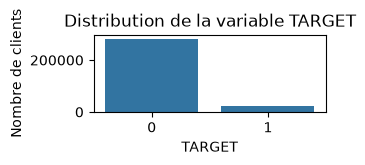

In [6]:
print(y_train.value_counts() , "\nPourcentage par classe :" , (y_train.value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(3, 1))
sns.countplot(x=y_train)
plt.title("Distribution de la variable TARGET")
plt.xlabel("TARGET")
plt.ylabel("Nombre de clients")
plt.show()

Dans Home Credit :
- `TARGET = 0` : absence de défaut ;
- `TARGET = 1` : défaut.

La cible est déséquilibrée : la classe `1` est minoritaire. C'est pourquoi le **ROC-AUC** est particulièrement utile pour évaluer le modèle.

## Identifier les valeurs manquantes

Au moment de construire nos modèles d'apprentissage automatique, nous devrons combler ces valeurs manquantes (une opération appelée imputation). Par la suite, nous utiliserons des modèles tels que LightGBM, capables de gérer les valeurs manquantes sans nécessiter d'imputation
Une autre solution consisterait à supprimer les colonnes présentant un taux élevé de valeurs manquantes, bien qu'il soit impossible de savoir à l'avance si ces colonnes seront utiles à notre modèle. Par conséquent, nous conserverons toutes les colonnes pour le moment.

In [7]:
missing_df = (
    X_train.isnull()
     .sum()
     .rename("missing_count")
     .to_frame()
     .assign(missing_percentage=lambda df: df["missing_count"] / len(X_train) * 100)
     .sort_values("missing_percentage", ascending=False)
)

missing_df.head(20)

,missing_count,missing_percentage
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


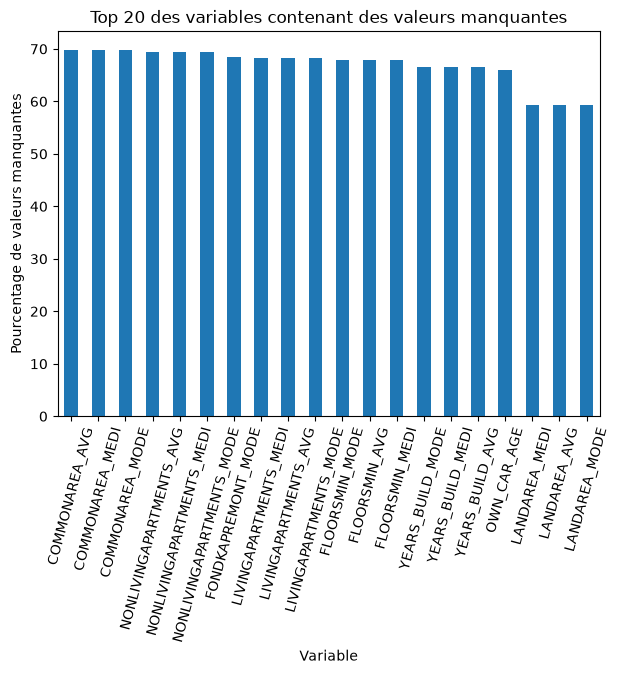

In [8]:
missing_df.head(20)["missing_percentage"].plot(kind="bar", figsize=(7, 5))
plt.title("Top 20 des variables contenant des valeurs manquantes")
plt.ylabel("Pourcentage de valeurs manquantes")
plt.xlabel("Variable")
plt.xticks(rotation=75)
plt.show()

## Types de colonnes 
Analyser le type de chaque colonne permet de savoir quelle transformation appliquer, car un algorithme de machine learning ne sait traiter nativement que des nombres.
1. Variables Numériques (Âge, Prix, Montant du prêt) Ce qu'on analyse : Sont-elles à des échelles très différentes ? Y a-t-il des valeurs très extrêmes ?  Action en feature engineering :  
    Normalisation / Standardisation : Ramener les valeurs sur une même échelle (ex: entre 0 et 1).  
    Discrétisation (Binning) : Transformer un nombre continu en tranches (ex: transformer l'âge en tranches : Jeune, Adulte, Senior).  
2. Variables Catégorielles (Type de contrat)Ce qu'on analyse : Y a-t-il un ordre logique (ex: Petit / Moyen / Grand) ou est-ce juste des étiquettes (ex: Paris / Lyon / Marseille) ?Action en feature engineering :  
    Encodage ordinal / Label Encoding : Convertir en 1, 2, 3 s'il y a une notion d'ordre.
    One-Hot Encoding : Créer une colonne binaire (0 ou 1) par catégorie si elles sont indépendantes.  
3. Dates et Heures (Date de transaction, Horodatage)Ce qu'on analyse : Une date brute (ex: 2026-07-31) n'est pas exploitable telle quelle par un modèle.
Action en feature engineering :
    Extraction : Séparer en Mois, Jour de la semaine, Heure, Est_un_week_end (Oui/Non).  
    Calcul de durée : Calculer l'écart par rapport à aujourd'hui (ex: Ancienneté du client en jours).
4. Textes Libres (Commentaires, Titre d'une annonce)Ce qu'on analyse : La présence de mots-clés ou la longueur du texte.  Action en feature engineering :  
    Extraire la longueur du texte, le nombre de mots, la présence d'un mot spécifique ou générer des vecteurs de mots (TF-IDF, Embeddings).  

In [9]:
print(df_train.dtypes.value_counts())
print("\nNombre de classes uniques par colonne catégorielle :")
print(df_train.select_dtypes("object").apply(pd.Series.nunique))


float64    65
int64      41
str        16
Name: count, dtype: int64

Nombre de classes uniques par colonne catégorielle :
NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64


### Analyse des variables temporelles (`DAYS_*`)
Dates et Heures (Date de transaction, Horodatage)Ce qu'on analyse : Une date brute (ex: 2026-07-31) n'est pas exploitable telle quelle par un modèle.
Action en feature engineering :
Extraction : Séparer en Mois, Jour de la semaine, Heure, Est_un_week_end (Oui/Non).  
Calcul de durée : Calculer l'écart par rapport à aujourd'hui (ex: Ancienneté du client en jours)

307511.0
365243.0
307511.0
307511.0


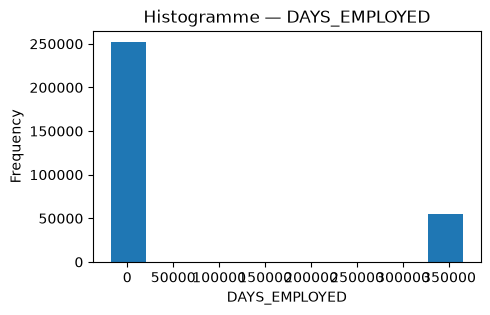

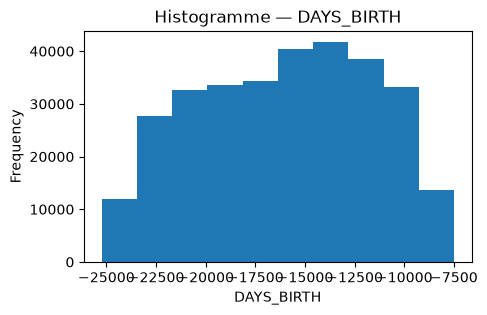

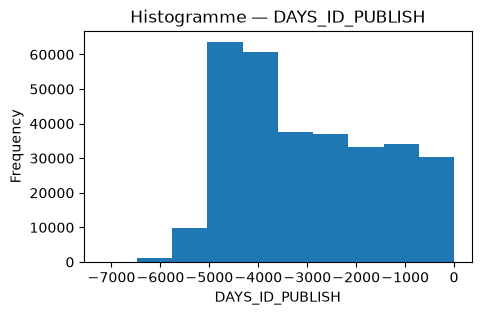

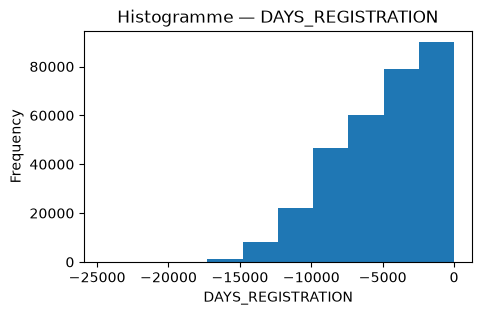

In [10]:
print(df_train["DAYS_BIRTH"].describe().max())
print(df_train["DAYS_EMPLOYED"].describe().max())
print(df_train["DAYS_ID_PUBLISH"].describe().max())
print(df_train["DAYS_REGISTRATION"].describe().max())

for col in ["DAYS_EMPLOYED", "DAYS_BIRTH", "DAYS_ID_PUBLISH", "DAYS_REGISTRATION"]:
    plt.figure(figsize=(5, 3))
    df_train[col].plot.hist(title=f"Histogramme — {col}")
    plt.xlabel(col)
    plt.show()


DAYS_EMPLOYED non conforme. Les 3 autres colonnes contenant le terme « DAYS » semblent conformes aux attentes, pas de valeurs aberrantes.

In [11]:
# Valeurs positives ou aberrantes (âge équivalent >= 120 ans)
for col in ["DAYS_REGISTRATION", "DAYS_ID_PUBLISH"]:
    pos_count = (df_train[col] > 0).sum()
    anom_count = ((df_train[col] / -365) >= 120).sum()
    print(f"--- {col} ---")
    print(f"Valeurs positives (> 0)          : {pos_count}")
    print(f"Valeurs aberrantes (>= 120 ans)  : {anom_count}")

# Incohérences par rapport à la date de naissance (DAYS_BIRTH)
incoherence_reg = (df_train["DAYS_REGISTRATION"] < df_train["DAYS_BIRTH"]).sum()
incoherence_id = (df_train["DAYS_ID_PUBLISH"] < df_train["DAYS_BIRTH"]).sum()

print(f"\nChangement d'adresse avant la naissance : {incoherence_reg}")
print(f"Changement d'ID avant la naissance       : {incoherence_id}")


--- DAYS_REGISTRATION ---
Valeurs positives (> 0)          : 0
Valeurs aberrantes (>= 120 ans)  : 0
--- DAYS_ID_PUBLISH ---
Valeurs positives (> 0)          : 0
Valeurs aberrantes (>= 120 ans)  : 0

Changement d'adresse avant la naissance : 1
Changement d'ID avant la naissance       : 0


### Rmplacer les outliers de (`DAYS_EMPLOYED`)
remplacer les anomalies dans DAYS_EMPLOYED par une valeur manquante nan, puis à les compléter via une imputation avant l'étape d'apprentissage automatique

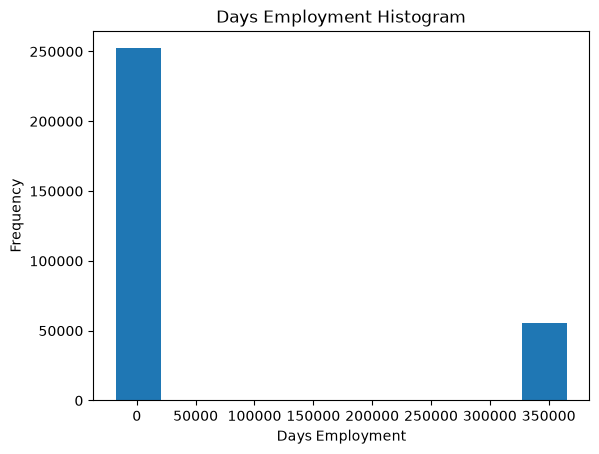

In [12]:
# Create an anomalous flag column
df_train['DAYS_EMPLOYED_ANOM'] = df_train["DAYS_EMPLOYED"] == 365243

# Replace the anomalous values with nan
df_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace = True)

df_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');

## Anomalie sur DAYS_BIRTH

`DAYS_BIRTH` représente l'âge en jours avant la date de référence. Une valeur correspondant à plus de 120 ans est considérée ici comme une anomalie. La correction est réalisée **après la séparation train/validation** afin d'éviter d'utiliser des statistiques de validation pour traiter le train.

In [13]:

def correct_days_birth(train_df, valid_df):
    train_df = train_df.copy()
    valid_df = valid_df.copy()

    if "DAYS_BIRTH" not in train_df.columns:
        return train_df, valid_df

    # Valeurs anormales : âge supérieur à 120 ans
    train_df.loc[train_df["DAYS_BIRTH"].abs() / 365 > 120, "DAYS_BIRTH"] = np.nan
    valid_df.loc[valid_df["DAYS_BIRTH"].abs() / 365 > 120, "DAYS_BIRTH"] = np.nan

    # Médianes calculées uniquement sur le train
    if "NAME_INCOME_TYPE" in train_df.columns:
        medians = train_df.groupby("NAME_INCOME_TYPE", observed=True)["DAYS_BIRTH"].median()
        train_df["DAYS_BIRTH"] = train_df["DAYS_BIRTH"].fillna(train_df["NAME_INCOME_TYPE"].map(medians))
        valid_df["DAYS_BIRTH"] = valid_df["DAYS_BIRTH"].fillna(valid_df["NAME_INCOME_TYPE"].map(medians))

    # Sécurité : médiane globale du train
    global_median = train_df["DAYS_BIRTH"].median()
    train_df["DAYS_BIRTH"] = train_df["DAYS_BIRTH"].fillna(global_median)
    valid_df["DAYS_BIRTH"] = valid_df["DAYS_BIRTH"].fillna(global_median)

    return train_df, valid_df


# X_train (DataFrame non standardisé, DAYS_BIRTH encore en jours bruts) est re-découpé
# spécifiquement pour cette démonstration de correction d'anomalie.
X_train_df, X_valid_df, _, _ = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

X_train_corr, X_valid_corr = correct_days_birth(X_train_df, X_valid_df)

print("Correction de DAYS_BIRTH terminée.")


Correction de DAYS_BIRTH terminée.


## Identifier les variables catégorielles


In [22]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Variables numériques :", len(numeric_features))
print("Variables catégorielles :", len(categorical_features))
print("\nNombre de classes uniques par colonne catégorielle :")
print(X_train[categorical_features].apply(pd.Series.nunique))


Variables numériques : 109
Variables catégorielles : 0

Nombre de classes uniques par colonne catégorielle :
Series([], dtype: float64)


## Préparation des variables catégorielles


In [23]:
X_train[categorical_features] = X_train[categorical_features].astype("category")
print(X_train.dtypes.value_counts())

bool       132
float64     65
int64       44
Name: count, dtype: int64


### Encodage des variables binaires (Label Encoding)

In [16]:
le = LabelEncoder()
binary_cols = [
    col for col in categorical_features if X_train[col].nunique() <= 2
]

for col in binary_cols:
    le.fit(X_train[col])
    X_train[col] = le.transform(X_train[col])
    df_train[col] = le.transform(df_train[col])
    df_test[col] = le.transform(df_test[col])

print("Variables binaires encodées (Label Encoding) :", binary_cols)


Variables binaires encodées (Label Encoding) : ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'EMERGENCYSTATE_MODE']


### Encodage des variables multi-catégorielles (One-Hot Encoding)

In [17]:
df_train = pd.get_dummies(df_train)
df_test = pd.get_dummies(df_test)
X_train = pd.get_dummies(X_train)

col = [c for c in X_train.columns if "NAME_INCOME_TYPE" in c][0]
print("Exemple de variable catégorielle transformée :")
print(X_train[col].value_counts())
print("\nDimensions de X_train :", X_train.shape)


Exemple de variable catégorielle transformée :
NAME_INCOME_TYPE_Businessman
False    307501
True         10
Name: count, dtype: int64

Dimensions de X_train : (307511, 241)


### Correlations
rechercher des corrélations entre les variables explicatives (features) et la variable cible. Nous pouvons calculer le coefficient de corrélation de Pearson entre chaque variable et la cible en utilisant la méthode `.corr`

In [18]:
# Find correlations with the target and sort
correlations = df_train.corr()['TARGET'].sort_values()

# Display correlations
print('Most Positive Correlations:\n', correlations.tail(15))
print('\nMost Negative Correlations:\n', correlations.head(15))

Most Positive Correlations:
 DAYS_REGISTRATION                                    0.041975
OCCUPATION_TYPE_Laborers                             0.043019
FLAG_DOCUMENT_3                                      0.044346
REG_CITY_NOT_LIVE_CITY                               0.044395
FLAG_EMP_PHONE                                       0.045982
NAME_EDUCATION_TYPE_Secondary / secondary special    0.049824
REG_CITY_NOT_WORK_CITY                               0.050994
DAYS_ID_PUBLISH                                      0.051457
CODE_GENDER_M                                        0.054713
DAYS_LAST_PHONE_CHANGE                               0.055218
NAME_INCOME_TYPE_Working                             0.057481
REGION_RATING_CLIENT                                 0.058899
REGION_RATING_CLIENT_W_CITY                          0.060893
DAYS_BIRTH                                           0.078239
TARGET                                               1.000000
Name: TARGET, dtype: float64

Most Negati

les corrélations positives indiquent que lorsque la valeur de la variable augmente, le risque de défaut (TARGET = 1) augmente également.

🔹 Âge et Ancienneté (DAYS_BIRTH, DAYS_EMPLOYED)
DAYS_BIRTH (+0.078) : Dans ce jeu de données, les jours sont exprimés sous forme négative par rapport au jour de la demande. Une valeur plus élevée (moins négative) correspond à un âge plus jeune.

Interprétation : Les clients les plus jeunes présentent un risque de défaut plus élevé.

DAYS_EMPLOYED (+0.075) : De même, une valeur moins négative signifie une ancienneté plus faible dans le travail actuel.

Interprétation : Les personnes récemment embauchées ou ayant une faible stabilité professionnelle sont plus à risque.

Les corrélations négatives indiquent que lorsque la valeur augmente, le risque de défaut diminue (TARGET tend vers 0).

🔹 Les Predictors majeurs : Scores Externes
EXT_SOURCE_3 (-0.179), EXT_SOURCE_2 (-0.160), EXT_SOURCE_1 (-0.155) :

Ce sont de loin les variables les plus influentes du jeu de données.

Ces scores normalisés issus d'organismes de crédit extérieurs sont de très bons indicateurs : plus le score externe est élevé, plus le client est fiable et enclin à rembourser son prêt.

### Sources extérieures
EXT_SOURCE_3 , EXT_SOURCE_2 , EXT_SOURCE_1

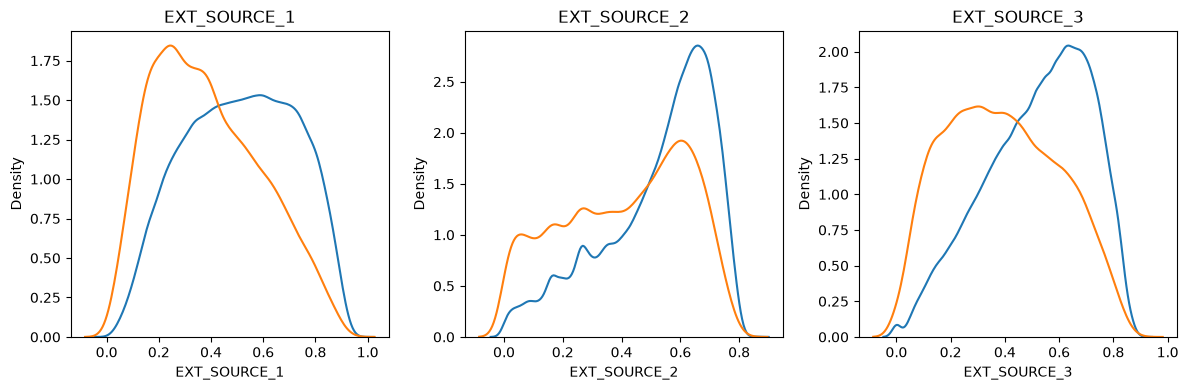

In [20]:
# Visualisation des distributions des 3 EXT_SOURCE selon la variable TARGET
plt.figure(figsize=(12, 4))
for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    plt.subplot(1, 3, i + 1)
    sns.kdeplot(df_train.loc[df_train['TARGET'] == 0, col], label='Target 0 (Remboursé)')
    sns.kdeplot(df_train.loc[df_train['TARGET'] == 1, col], label='Target 1 (Défaut)')
    plt.title(col)
plt.tight_layout()
plt.show()

Ce graphique montre la répartition des scores pour les clients qui ont remboursé (Bleu : TARGET 0) vs ceux en défaut (Orange : TARGET 1).Séparation nette des classes : Pour les 3 scores, la courbe orange (défaut) est décalée vers la gauche et la courbe bleue (remboursé) vers la droite.Constat clé :Un score faible ($< 0.3$) indique une probabilité plus forte de défaut de paiement.Un score élevé ($> 0.6$) indique un client fiable.Conclusion : Ces 3 variables ont un fort pouvoir impactant.



## Pairs Plot


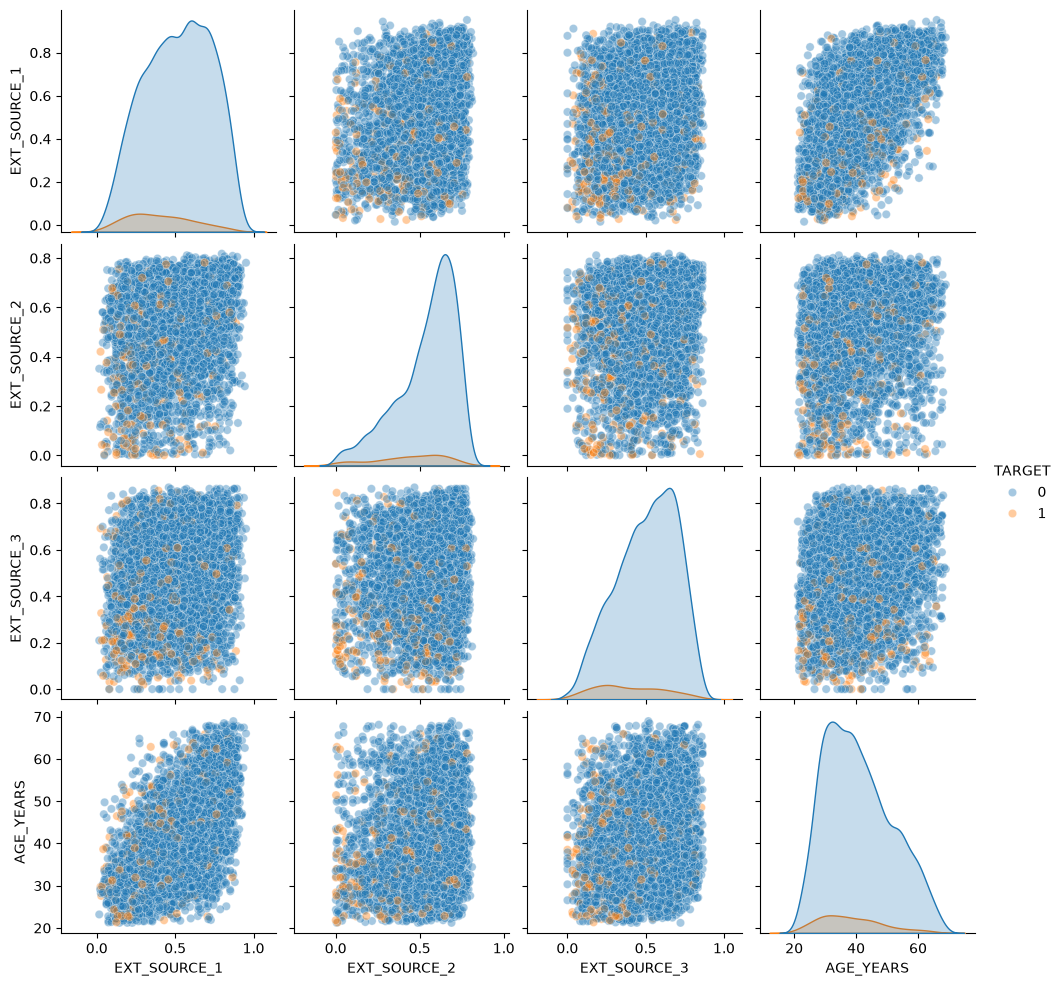

In [28]:
# Sélection restreinte aux variables clés + TARGET
ext_data = df_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']].dropna()

# Convertir DAYS_BIRTH en années positives pour une lecture plus claire
ext_data['AGE_YEARS'] = -ext_data['DAYS_BIRTH'] / 365
ext_data = ext_data.drop(columns=['DAYS_BIRTH'])

# Pair Plot restreint (échantillonné à 5000 points pour être fluide)
sns.pairplot(ext_data.sample(5000, random_state=42), hue='TARGET', diag_kind='kde', plot_kws={'alpha': 0.4})
plt.show()

Le Pair Plot analyse les relations deux à deux entre EXT_SOURCE_1, 2, 3 et l'âge (AGE_YEARS).

Sur la diagonale (Distributions) : On retrouve les densités cumulées, montrant un déséquilibre de classe important (beaucoup plus de TARGET = 0 que de TARGET = 1).

Nuages de points (Scatter plots) :

Absence de colinéarité : Les points s'éparpillent de manière homogène sans former de lignes distinctes. Les 3 scores EXT_SOURCE apportent donc des informations complémentaires et non redondantes.

Tendance avec l'âge (AGE_YEARS) : On observe une légère pente positive entre l'âge et EXT_SOURCE_1. Les clients plus âgés ont tendance à avoir un score EXT_SOURCE_1 légèrement plus élevé et à moins faire défaut (moins de points oranges vers le bas/jeune âge).

# Feature Engineering

Deux méthodes simples de construction de features sont utilisées ici :
* Polynomial Features
* Domain Knowledge Features

## Polynomial Features

On construit des features qui sont des puissances de variables existantes ainsi que des termes d'interaction entre elles (ex : `EXT_SOURCE_1^2`, `EXT_SOURCE_1` x `EXT_SOURCE_2`, etc.). Ces combinaisons peuvent révéler une relation avec la cible même lorsque les variables prises isolément n'en ont pas.

On utilise ici les variables `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` et `DAYS_BIRTH`, avec un degré polynomial de 3 (`PolynomialFeatures` de Scikit-Learn).

In [26]:
# Création des features polynomiales à partir des scores EXT_SOURCE et de DAYS_BIRTH
poly_features = df_train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'TARGET']].copy()
poly_features_test = df_test[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']].copy()

# Imputer pour gérer les valeurs manquantes
from sklearn.impute import SimpleImputer
poly_imputer = SimpleImputer(strategy='median')

poly_target = poly_features['TARGET']
poly_features = poly_features.drop(columns=['TARGET'])

# Imputation des valeurs manquantes
poly_features = poly_imputer.fit_transform(poly_features)
poly_features_test = poly_imputer.transform(poly_features_test)

from sklearn.preprocessing import PolynomialFeatures

# Création de l'objet polynomial de degré 3
poly_transformer = PolynomialFeatures(degree=3)

In [29]:
# Entraînement et transformation des features polynomiales
poly_transformer.fit(poly_features)

poly_features = poly_transformer.transform(poly_features)
poly_features_test = poly_transformer.transform(poly_features_test)
print('Dimensions des features polynomiales : ', poly_features.shape)


Dimensions des features polynomiales :  (307511, 35)


Pour récupérer les noms des 35 nouvelles features (puissances jusqu'au degré 3 et termes d'interaction), on utilise la méthode `get_feature_names_out`.

In [30]:
# Noms des features polynomiales générées
poly_transformer.get_feature_names_out(
    input_features=['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']
)[:15]

array(['1', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH',
       'EXT_SOURCE_1^2', 'EXT_SOURCE_1 EXT_SOURCE_2',
       'EXT_SOURCE_1 EXT_SOURCE_3', 'EXT_SOURCE_1 DAYS_BIRTH',
       'EXT_SOURCE_2^2', 'EXT_SOURCE_2 EXT_SOURCE_3',
       'EXT_SOURCE_2 DAYS_BIRTH', 'EXT_SOURCE_3^2',
       'EXT_SOURCE_3 DAYS_BIRTH', 'DAYS_BIRTH^2'], dtype=object)

On peut ensuite vérifier si certaines de ces nouvelles variables sont plus corrélées à la cible que les variables d'origine.

In [31]:
# Dataframe des features polynomiales + corrélations avec la cible
poly_features = pd.DataFrame(
    poly_features,
    columns=poly_transformer.get_feature_names_out(
        ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']
    )
)

# Ajout de la cible
poly_features['TARGET'] = poly_target

# Corrélations avec la cible
poly_corrs = poly_features.corr()['TARGET'].sort_values()

print('Corrélations les plus négatives :\n', poly_corrs.head(10))
print('\nCorrélations les plus positives :\n', poly_corrs.tail(5))

Corrélations les plus négatives :
 EXT_SOURCE_2 EXT_SOURCE_3                -0.193939
EXT_SOURCE_1 EXT_SOURCE_2 EXT_SOURCE_3   -0.189605
EXT_SOURCE_2^2 EXT_SOURCE_3              -0.176428
EXT_SOURCE_2 EXT_SOURCE_3^2              -0.172282
EXT_SOURCE_1 EXT_SOURCE_2                -0.166625
EXT_SOURCE_1 EXT_SOURCE_3                -0.164065
EXT_SOURCE_2                             -0.160295
EXT_SOURCE_1 EXT_SOURCE_2^2              -0.156867
EXT_SOURCE_3                             -0.155892
EXT_SOURCE_1 EXT_SOURCE_3^2              -0.150822
Name: TARGET, dtype: float64

Corrélations les plus positives :
 EXT_SOURCE_1 EXT_SOURCE_2 DAYS_BIRTH    0.155891
EXT_SOURCE_2 DAYS_BIRTH                 0.156873
EXT_SOURCE_2 EXT_SOURCE_3 DAYS_BIRTH    0.181283
TARGET                                  1.000000
1                                            NaN
Name: TARGET, dtype: float64


Ces nouvelles features sont fusionnées dans une copie des jeux d'entraînement et de test, afin de pouvoir comparer les performances des modèles avec et sans ces variables.

In [32]:
#  Fusion des features polynomiales dans les jeux train / test
poly_features_test = pd.DataFrame(
    poly_features_test,
    columns=poly_transformer.get_feature_names_out(
        ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']
    )
)

poly_features['SK_ID_CURR'] = df_train['SK_ID_CURR']
df_train_poly = df_train.merge(poly_features, on='SK_ID_CURR', how='left')

poly_features_test['SK_ID_CURR'] = df_test['SK_ID_CURR']
df_test_poly = df_test.merge(poly_features_test, on='SK_ID_CURR', how='left')

# Alignement des colonnes entre train et test
df_train_poly, df_test_poly = df_train_poly.align(df_test_poly, join='inner', axis=1)

print('Dimensions du train avec features polynomiales :', df_train_poly.shape)
print('Dimensions du test avec features polynomiales  :', df_test_poly.shape)

Dimensions du train avec features polynomiales : (307511, 273)
Dimensions du test avec features polynomiales  : (48744, 273)


## Domain Knowledge Features

En s'inspirant de connaissances métier sur le crédit, on construit quatre variables :
* `CREDIT_INCOME_PERCENT` : pourcentage du montant du crédit par rapport au revenu du client
* `ANNUITY_INCOME_PERCENT` : pourcentage de l'annuité du prêt par rapport au revenu du client
* `CREDIT_TERM` : durée du remboursement en mois (l'annuité étant le montant mensuel dû)
* `DAYS_EMPLOYED_PERCENT` : pourcentage du nombre de jours d'emploi par rapport à l'âge du client

In [33]:
# Création des features de connaissance métier — jeu d'entraînement
df_train_domain = df_train.copy()
df_test_domain = df_test.copy()

df_train_domain['CREDIT_INCOME_PERCENT'] = df_train_domain['AMT_CREDIT'] / df_train_domain['AMT_INCOME_TOTAL']
df_train_domain['ANNUITY_INCOME_PERCENT'] = df_train_domain['AMT_ANNUITY'] / df_train_domain['AMT_INCOME_TOTAL']
df_train_domain['CREDIT_TERM'] = df_train_domain['AMT_ANNUITY'] / df_train_domain['AMT_CREDIT']
df_train_domain['DAYS_EMPLOYED_PERCENT'] = df_train_domain['DAYS_EMPLOYED'] / df_train_domain['DAYS_BIRTH']

In [34]:
# Création des features de connaissance métier — jeu de test
df_test_domain['CREDIT_INCOME_PERCENT'] = df_test_domain['AMT_CREDIT'] / df_test_domain['AMT_INCOME_TOTAL']
df_test_domain['ANNUITY_INCOME_PERCENT'] = df_test_domain['AMT_ANNUITY'] / df_test_domain['AMT_INCOME_TOTAL']
df_test_domain['CREDIT_TERM'] = df_test_domain['AMT_ANNUITY'] / df_test_domain['AMT_CREDIT']
df_test_domain['DAYS_EMPLOYED_PERCENT'] = df_test_domain['DAYS_EMPLOYED'] / df_test_domain['DAYS_BIRTH']

#### Visualiser les nouvelles variables

On explore visuellement ces variables de connaissance métier via un graphique de densité (KDE) coloré selon la valeur de `TARGET`.

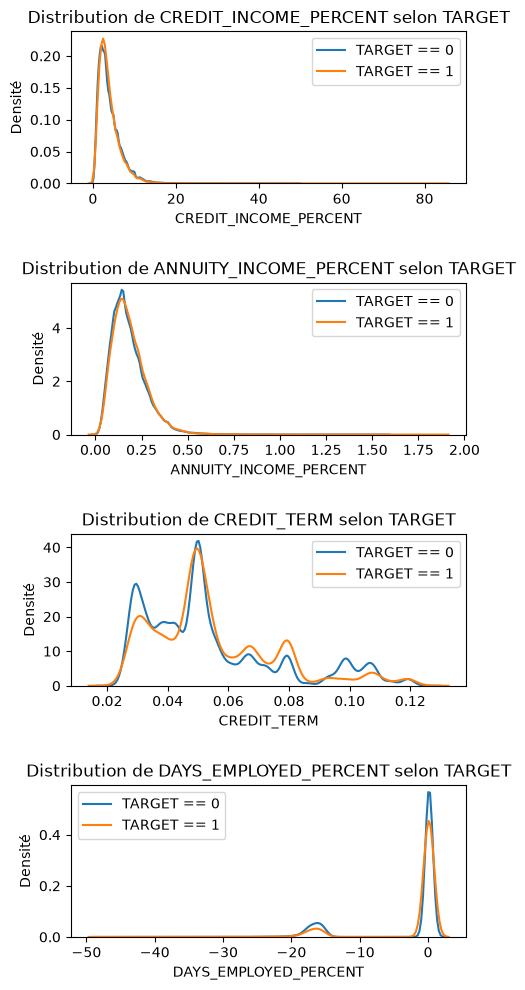

In [35]:
# Visualisation des nouvelles variables "domain knowledge"
plt.figure(figsize=(5, 10))
for i, feature in enumerate(['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT']):
    plt.subplot(4, 1, i + 1)
    sns.kdeplot(df_train_domain.loc[df_train_domain['TARGET'] == 0, feature], label='TARGET == 0')
    sns.kdeplot(df_train_domain.loc[df_train_domain['TARGET'] == 1, feature], label='TARGET == 1')
    plt.title('Distribution de %s selon TARGET' % feature)
    plt.xlabel(feature)
    plt.ylabel('Densité')
    plt.legend()
plt.tight_layout(h_pad=2.5)
plt.show()

Il est difficile de savoir à l'avance si ces nouvelles features seront utiles pour le modèle : la seule manière de le vérifier est de les tester dans la partie Baseline.

## Séparation Train / Validation + imputation et normalisation


In [38]:
train = X_train.copy()
test = df_test.copy()
train, test = train.align(test, join="inner", axis=1)

# Noms des variables (sauvegardés après l'alignement train/test)
features = list(train.columns)

# Imputation par la médiane
imputer = SimpleImputer(strategy="median")
train = imputer.fit_transform(train)
test = imputer.transform(test)

# Normalisation min-max
scaler = MinMaxScaler(feature_range=(0, 1))
train = scaler.fit_transform(train)
test = scaler.transform(test)

print("Train :", train.shape)
print("Test  :", test.shape)


Train : (307511, 238)
Test  : (48744, 238)


In [52]:
print(test)

[[-2.80699391e-06  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   1.00000000e+00  0.00000000e+00]
 [ 8.42098172e-06  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 3.08769330e-05  0.00000000e+00  1.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [ 9.99910176e-01  0.00000000e+00  1.00000000e+00 ...  0.00000000e+00
   1.00000000e+00  0.00000000e+00]
 [ 9.99912983e-01  0.00000000e+00  0.00000000e+00 ...  1.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 9.99985965e-01  0.00000000e+00  1.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]


## Analyse en Composantes Principales (ACP / PCA)

In [37]:
from sklearn.preprocessing import StandardScaler

### Preparation & Scaling of Numerical Data for PCA

In [38]:
# --- 1. SÉLECTION ET NORMALISATION DES VARIABLES NUMÉRIQUES POUR L'ACP ---
# L'ACP nécessite des données numériques sans valeurs manquantes et centrées-réduites.

# Identification des colonnes numériques
numeric_cols = X_train.select_dtypes(include=[np.number]).columns

# Imputation par la médiane pour les valeurs manquantes
imputer_pca = SimpleImputer(strategy="median")
X_train_num_imputed = imputer_pca.fit_transform(X_train[numeric_cols])

# Standardisation (Centrer-Réduire : moyenne = 0, variance = 1)
scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_train_num_imputed)

print(
    f"Dimensions de la matrice normalisée pour l'ACP : {X_train_scaled.shape}"
)

Dimensions de la matrice normalisée pour l'ACP : (307511, 109)


### Variance Explication & Scree Plot

Nombre de composantes pour expliquer 80% de la variance : 43
Nombre de composantes pour expliquer 90% de la variance : 55


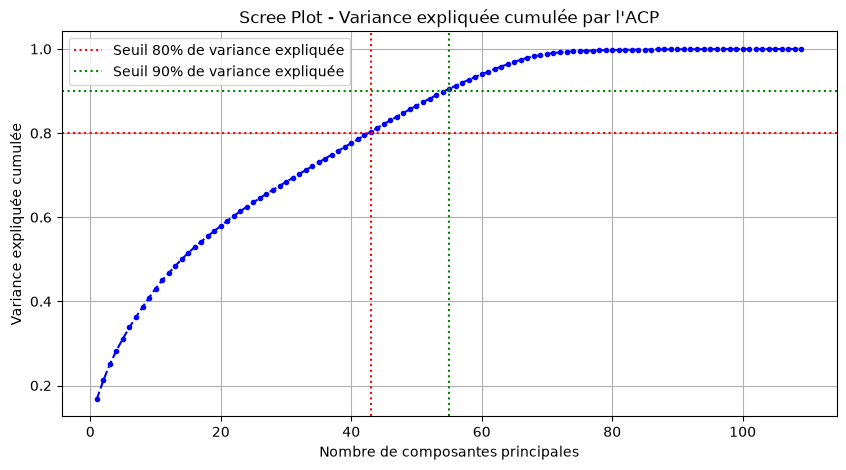

In [39]:
# --- 2. CALCUL DE L'ACP ET VISUALISATION DE LA VARIANCE EXPLIQUÉE ---

# Instanciation de l'ACP sur toutes les composantes
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Variance expliquée et variance cumulée
exp_var = pca_full.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

# Recherche du nombre de composantes pour atteindre 80% et 90% de variance expliquée
n_components_80 = np.argmax(cum_exp_var >= 0.80) + 1
n_components_90 = np.argmax(cum_exp_var >= 0.90) + 1

print(
    f"Nombre de composantes pour expliquer 80% de la variance : {n_components_80}"
)
print(
    f"Nombre de composantes pour expliquer 90% de la variance : {n_components_90}"
)

# Graphique de la variance cumulée (Scree Plot)
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(cum_exp_var) + 1),
    cum_exp_var,
    marker="o",
    linestyle="--",
    color="b",
    markersize=3,
)
plt.axhline(
    y=0.80, color="r", linestyle=":", label="Seuil 80% de variance expliquée"
)
plt.axhline(
    y=0.90, color="g", linestyle=":", label="Seuil 90% de variance expliquée"
)
plt.axvline(x=n_components_80, color="r", linestyle=":")
plt.axvline(x=n_components_90, color="g", linestyle=":")
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Variance expliquée cumulée")
plt.title("Scree Plot - Variance expliquée cumulée par l'ACP")
plt.legend(loc="best")
plt.grid(True)
plt.show()

### Projection Visualisation on First 2 Principal Components

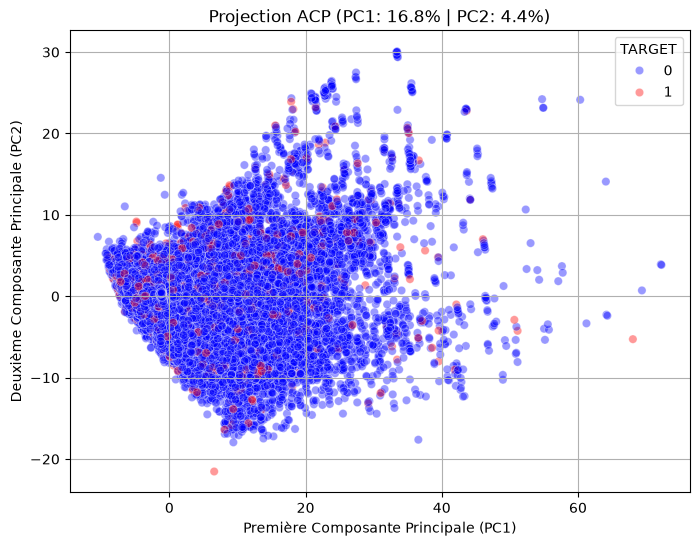

In [40]:
# --- 3. PROJECTION ET VISUALISATION SUR LES DEUX PREMIERS AXES (PC1 & PC2) ---

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_train_scaled)

df_pca_2d = pd.DataFrame(
    data=X_pca_2d, columns=["Composante_1", "Composante_2"]
)
df_pca_2d["TARGET"] = y_train.values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="Composante_1",
    y="Composante_2",
    hue="TARGET",
    data=df_pca_2d,
    alpha=0.4,
    palette={0: "blue", 1: "red"},
)
plt.title(
    f"Projection ACP (PC1: {pca_2d.explained_variance_ratio_[0]*100:.1f}% | PC2: {pca_2d.explained_variance_ratio_[1]*100:.1f}%)"
)
plt.xlabel("Première Composante Principale (PC1)")
plt.ylabel("Deuxième Composante Principale (PC2)")
plt.grid(True)
plt.show()

### Transformation & Storing PCA Features

In [41]:
# --- 4. CRÉATION DU DATAFRAME AVEC LES COMPOSANTES CONSERVÉES (EX: 90% VARIANCE) ---

# Application de la réduction de dimension à n_components_90
pca_selected = PCA(n_components=n_components_90)
X_train_pca = pca_selected.fit_transform(X_train_scaled)

# Conversion en DataFrame Pandas avec nommage explicite
pca_cols = [f"PC_{i+1}" for i in range(n_components_90)]
df_X_train_pca = pd.DataFrame(X_train_pca, columns=pca_cols)

print(
    f"Nouveau jeu de données réduit par ACP : {df_X_train_pca.shape[0]} lignes, {df_X_train_pca.shape[1]} composantes"
)
df_X_train_pca.head()

Nouveau jeu de données réduit par ACP : 307511 lignes, 55 composantes


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_46,PC_47,PC_48,PC_49,PC_50,PC_51,PC_52,PC_53,PC_54,PC_55
0,-4.962121,1.189265,0.541596,-1.107787,1.282242,-0.728503,-0.333710,3.593069,3.958770,-0.731387,...,0.005684,-0.131784,0.313947,0.806317,-0.462162,-0.851105,0.677165,-0.061216,-1.976277,0.192508
1,0.265853,-4.966806,0.178465,-0.981297,-0.646764,0.271092,0.797584,-0.214674,-0.177718,-1.126455,...,0.032128,-0.151908,-0.090510,0.046164,-0.125744,-0.151087,0.090209,0.368422,-1.339422,1.304440
2,-1.165987,0.522973,-0.523067,1.351902,0.496254,-0.967738,-2.222681,-0.565752,-0.513348,-0.215571,...,-0.123224,-0.724247,0.408459,-0.062771,-0.648775,0.398806,-0.543722,0.960957,-1.120456,-0.500492
3,-1.120818,0.330548,-0.462557,0.366348,-0.149588,-0.102475,-0.165632,0.002310,0.101453,-0.321985,...,-0.069417,-0.024896,0.024497,-0.070871,-0.048716,0.300147,-0.623337,-0.952103,0.089896,-0.413938
4,-1.154360,-0.001263,0.448275,0.409312,-0.367791,-0.135563,-0.940497,-1.463250,-0.170267,1.153293,...,0.779124,-0.170126,0.360665,-0.253485,-0.674007,-0.475693,0.463368,-0.132802,0.850077,-0.360127


## SAUVEGARDE DES DATASETS AU FORMAT PARQUET

In [53]:
# Sauvegarde du jeu d'entraînement (Train + TARGET)
#pd.DataFrame(train).to_parquet('./input/train_engineered.parquet', index=False)
pd.DataFrame(train, columns=features).assign(TARGET=y_train.values).to_parquet('./input/train_engineered.parquet', index=False)
print("Train sauvegardé avec succès sous './input/train_engineered.parquet'")

# Sauvegarde du jeu de test (Test)
pd.DataFrame(test, columns=features).to_parquet('./input/test_engineered.parquet', index=False)
print("Test sauvegardé avec succès sous './input/test_engineered.parquet'")

"""# Sauvegarde de TARGET (en convertissant en Pandas Series)
pd.DataFrame(y_train, columns=['TARGET']).to_parquet('./input/target.parquet', index=False)
print("Target sauvegardée avec succès")"""

"""y_train.to_parquet('./input/target.parquet', index=False)
print("Target sauvegardé avec succès sous './input/target.parquet'")"""



Train sauvegardé avec succès sous './input/train_engineered.parquet'
Test sauvegardé avec succès sous './input/test_engineered.parquet'


'y_train.to_parquet(\'./input/target.parquet\', index=False)\nprint("Target sauvegardé avec succès sous \'./input/target.parquet\'")'